In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn

import torch
cuda = torch.cuda.is_available()
print("GPU:", cuda)

GPU: False


In [2]:
train = pd.read_csv("data/MNIST_CSV/mnist_train.csv")
train.head()

,5,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
X = train.iloc[:,1:].values / 255
Y = train.iloc[:,0].values

In [4]:
from sklearn.model_selection import train_test_split

trn_x,val_x,trn_y,val_y = train_test_split(X,Y,test_size=0.2)

In [5]:
#converting our data into a datloader object.

trn_x = torch.from_numpy(trn_x).type(torch.FloatTensor).view(-1,28,28)
trn_y = torch.from_numpy(trn_y).type(torch.LongTensor)

val_x = torch.from_numpy(val_x).type(torch.FloatTensor).view(-1,28,28)
val_y = torch.from_numpy(val_y).type(torch.LongTensor)

In [6]:
trn_x.shape

torch.Size([47999, 28, 28])

In [7]:
from torch.utils.data import TensorDataset,DataLoader

trn = TensorDataset(trn_x,trn_y)
trn = DataLoader(trn,batch_size=1000)

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class LSTM_Model(nn.Module):
    def __init__(self):
        super(LSTM_Model, self).__init__()

        self.rnn = nn.LSTM(         # if use nn.RNN(), it hardly learns
            input_size=28,
            hidden_size=64,         # rnn hidden unit
            num_layers=1,           # number of rnn layer
            batch_first=True,       # input & output will has batch size as 1s dimension. e.g. (batch, time_step, input_size)
        )

        self.out = nn.Linear(64, 10)

    def forward(self, x):
        # x shape (batch, time_step, input_size)
        # r_out shape (batch, time_step, output_size)
        # h_n shape (n_layers, batch, hidden_size)
        # h_c shape (n_layers, batch, hidden_size)
        r_out, (h_n, h_c) = self.rnn(x, None)   # None represents zero initial hidden state

        # choose r_out at the last time step
        out = self.out(r_out[:, -1, :])
        return out

lstm_model = LSTM_Model()

print(lstm_model)

LSTM_Model(
  (rnn): LSTM(28, 64, batch_first=True)
  (out): Linear(in_features=64, out_features=10, bias=True)
)


# Training

In [9]:
#define our optimizer
from torch.optim import Adam

optimizer = Adam(lstm_model.parameters(), lr=1e-3)

def compute_val_loss(val_x,val_y,model):
    model.eval()
    output = model(val_x)
    loss = F.cross_entropy(output,val_y)
    return loss

In [10]:
EPOCHS = 10

trn_loss = []
val_loss = []


for epoch in range(EPOCHS):
    for batch_idx, (data, target) in enumerate(trn):
        lstm_model.train()
        optimizer.zero_grad()
        y_pred = lstm_model(data)
        loss = F.cross_entropy(y_pred, target)
        trn_loss.append(loss.cpu().data.item())
        
        loss.backward()
        optimizer.step()
        
        loss = compute_val_loss(val_x,val_y,lstm_model)
        val_loss.append(loss.cpu().data.item())

    print("Epoch: {} | loss: {} | val_loss: {}".format(epoch+1,trn_loss[-1],val_loss[-1]))

Epoch: 1 | loss: 1.8447543382644653 | val_loss: 1.8488285541534424
Epoch: 2 | loss: 0.840860903263092 | val_loss: 0.8153378963470459
Epoch: 3 | loss: 0.48186203837394714 | val_loss: 0.4796488583087921
Epoch: 4 | loss: 0.3390781879425049 | val_loss: 0.3447391390800476
Epoch: 5 | loss: 0.2770330309867859 | val_loss: 0.2857400178909302
Epoch: 6 | loss: 0.2414819449186325 | val_loss: 0.2482454478740692
Epoch: 7 | loss: 0.20899641513824463 | val_loss: 0.22877129912376404
Epoch: 8 | loss: 0.18531818687915802 | val_loss: 0.21746952831745148
Epoch: 9 | loss: 0.1837553232908249 | val_loss: 0.19073998928070068
Epoch: 10 | loss: 0.1745341718196869 | val_loss: 0.1843603253364563


# evaluation

In [11]:
def predict_with_pytorch(model,val_x):
    model.eval()
    y_preds = []
    
    out = model(val_x)
    _, predicted = torch.max(out.data,1)
    
    for p in predicted:
        y_preds.append(p.detach().cpu().numpy().item())
        
        
    return y_preds    

Accuracy: 94.6 %


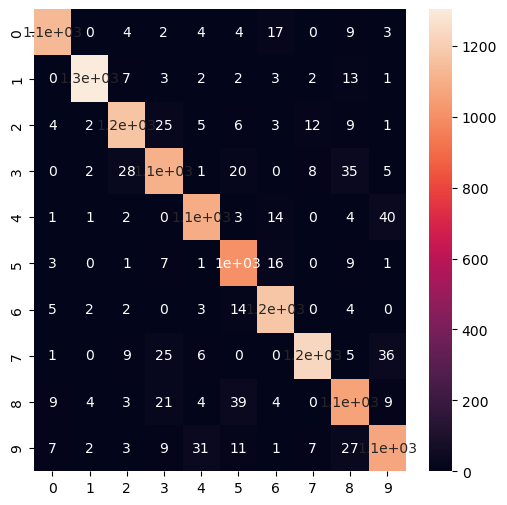

In [20]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

pred = predict_with_pytorch(lstm_model,val_x)
cm = confusion_matrix(val_y.numpy(),pred)
plt.figure(figsize = (6,6),dpi=100)
seaborn.heatmap(cm,annot=True)
acc = accuracy_score(val_y.numpy(),pred)
print("Accuracy:",acc*100,"%")

# RNN model

In [13]:
class RNN_Model(nn.Module):
    def __init__(self):
        super(RNN_Model, self).__init__()

        self.rnn = nn.RNN(         # if use nn.RNN(), it hardly learns
            input_size=28,
            hidden_size=64,         # rnn hidden unit
            num_layers=1,           # number of rnn layer
            batch_first=True,       # input & output will has batch size as 1s dimension. e.g. (batch, time_step, input_size)
        )

        self.out = nn.Linear(64, 10)

    def forward(self, x):
        # x shape (batch, time_step, input_size)
        
        # r_out shape (batch, time_step, output_size)
        # h_n shape (n_layers, batch, hidden_size)
        r_out, h_n = self.rnn(x, None)   # None represents zero initial hidden state

        # choose r_out at the last time step
        out = self.out(r_out[:, -1, :])
        return out

rnn_model = RNN_Model()

In [14]:
optimizer = Adam(rnn_model.parameters(), lr=1e-3)

trn_loss_rnn = []
val_loss_rnn = []


for epoch in range(EPOCHS):
    for batch_idx, (data, target) in enumerate(trn):
        rnn_model.train()
        optimizer.zero_grad()
        y_pred = rnn_model(data)
        loss = F.cross_entropy(y_pred, target)
        trn_loss_rnn.append(loss.cpu().data.item())
        
        loss.backward()
        optimizer.step()
        
        loss = compute_val_loss(val_x,val_y,rnn_model)
        val_loss_rnn.append(loss.cpu().data.item())

    print("Epoch: {} | loss: {} | val_loss: {}".format(epoch+1,trn_loss[-1],val_loss[-1]))

Epoch: 1 | loss: 0.1745341718196869 | val_loss: 0.1843603253364563
Epoch: 2 | loss: 0.1745341718196869 | val_loss: 0.1843603253364563
Epoch: 3 | loss: 0.1745341718196869 | val_loss: 0.1843603253364563
Epoch: 4 | loss: 0.1745341718196869 | val_loss: 0.1843603253364563
Epoch: 5 | loss: 0.1745341718196869 | val_loss: 0.1843603253364563
Epoch: 6 | loss: 0.1745341718196869 | val_loss: 0.1843603253364563
Epoch: 7 | loss: 0.1745341718196869 | val_loss: 0.1843603253364563
Epoch: 8 | loss: 0.1745341718196869 | val_loss: 0.1843603253364563
Epoch: 9 | loss: 0.1745341718196869 | val_loss: 0.1843603253364563
Epoch: 10 | loss: 0.1745341718196869 | val_loss: 0.1843603253364563


Accuracy: 77.10000000000001 %


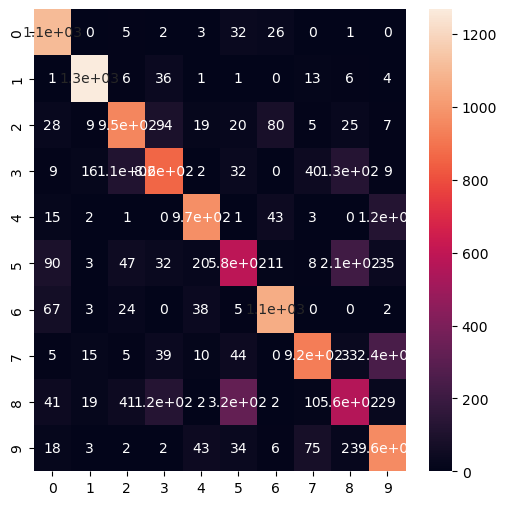

In [19]:
# prediction

pred = predict_with_pytorch(rnn_model,val_x)
cm = confusion_matrix(val_y.numpy(),pred)
plt.figure(figsize = (6,6),dpi=100)
seaborn.heatmap(cm,annot=True)
acc = accuracy_score(val_y.numpy(),pred)
print("Accuracy:",acc*100,"%")